<a href="https://colab.research.google.com/github/Sadifs/text-analytics-a3-jamjoom-sarbazi/blob/main/04_model2_nmf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Model 2: NMF Topic Modeling
**Course:** BSAN 6200  
**Assignment:** Topic Modeling  
**Student Role:** Student B  
**Dataset:** Disneyland Reviews Processed: (California, Paris, Hong Kong)

This notebook implements Model 2 (NMF) across all three Disneyland review groups, evaluates candidate topic counts, selects a final topic solution, and prepares outputs for manual interpretation.

## 1. Load the File





In [1]:
import pandas as pd
import ast

df = pd.read_csv("/content/disneyland_reviews_processed.csv")

df["tokens_lemma"] = df["tokens_lemma"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

print(df.shape)
print(df.columns.tolist())
print(df["location_clean"].value_counts())

(42462, 10)
['location', 'review_text', 'rating', 'location_clean', 'tokens_lemma', 'tokens_no_lemma', 'clean_text_lemma', 'clean_text_no_lemma', 'token_count_lemma', 'token_count_no_lemma']
location_clean
California    19268
Paris         13595
Hong Kong      9599
Name: count, dtype: int64


## 2. Install & Import

In [2]:
!pip install -q gensim wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.4 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

## 3. Make folders

In [4]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## 4. Define setup

In [5]:
target_groups = ["California", "Paris", "Hong Kong"]
text_col = "clean_text_lemma"

## 5. Helper Functions

In [6]:
def get_group_data(df, group_name, text_column):
    subset = df[df["location_clean"] == group_name].copy().reset_index(drop=True)
    docs = subset[text_column].fillna("").tolist()
    token_lists = subset["tokens_lemma"].tolist()
    return subset, docs, token_lists

def get_topic_words(model, feature_names, top_n=20):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_ids = topic.argsort()[::-1][:top_n]
        words = [feature_names[i] for i in top_ids]
        rows.append({
            "topic_id": topic_idx + 1,
            "top_words": ", ".join(words)
        })
    return pd.DataFrame(rows)

def get_coherence(topic_word_lists, token_lists):
    dictionary = Dictionary(token_lists)
    cm = CoherenceModel(
        topics=topic_word_lists,
        texts=token_lists,
        dictionary=dictionary,
        coherence="c_v"
    )
    return cm.get_coherence()

## 6. Add the NMF evaluation function

In [7]:
def evaluate_nmf(docs, token_lists, k_values=[5, 8, 10, 12, 15],
                 min_df=10, max_df=0.85, ngram_range=(1, 2),
                 random_state=42, max_iter=300, top_n_words=20):

    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range
    )

    dtm = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()

    results = []
    fitted_models = {}

    for k in k_values:
        model = NMF(
            n_components=k,
            random_state=random_state,
            max_iter=max_iter,
            init="nndsvda"
        )

        doc_topic = model.fit_transform(dtm)

        topic_word_lists = []
        for topic in model.components_:
            top_ids = topic.argsort()[::-1][:top_n_words]
            topic_words = [feature_names[i] for i in top_ids]
            topic_word_lists.append(topic_words)

        coherence = get_coherence(topic_word_lists, token_lists)

        results.append({
            "k": k,
            "coherence_c_v": coherence
        })

        fitted_models[k] = {
            "model": model,
            "vectorizer": vectorizer,
            "dtm": dtm,
            "feature_names": feature_names,
            "doc_topic": doc_topic,
            "topic_word_lists": topic_word_lists
        }

    results_df = pd.DataFrame(results).sort_values("coherence_c_v", ascending=False)
    return results_df, fitted_models

## 7. Run NMF for all 3 groups

In [8]:
nmf_artifacts = {}

for group in target_groups:
    print(f"\nRunning NMF for {group}...")

    subset, docs, token_lists = get_group_data(df, group, text_col)

    results_df, fitted_models = evaluate_nmf(
        docs=docs,
        token_lists=token_lists,
        min_df=10,
        max_df=0.85,
        ngram_range=(1, 2)
    )

    nmf_artifacts[group] = {
        "subset": subset,
        "docs": docs,
        "token_lists": token_lists,
        "results_df": results_df,
        "fitted_models": fitted_models
    }

    display(results_df)


Running NMF for California...


,k,coherence_c_v
0,5,0.539436
1,8,0.519165
4,15,0.513591
3,12,0.504995
2,10,0.503824



Running NMF for Paris...


,k,coherence_c_v
0,5,0.513130
4,15,0.495800
1,8,0.490376
2,10,0.488426
3,12,0.488020



Running NMF for Hong Kong...


,k,coherence_c_v
2,10,0.523944
4,15,0.503653
0,5,0.497808
3,12,0.496363
1,8,0.496231


## 8. Set final K

In [9]:
selected_k = {
    "California": 10,
    "Paris": 10,
    "Hong Kong": 10
}

## 9. Get the top words

In [11]:
nmf_topic_tables = {}

for group in target_groups:
    k = selected_k[group]
    fitted = nmf_artifacts[group]["fitted_models"][k]

    topic_table = get_topic_words(
        fitted["model"],
        fitted["feature_names"],
        top_n=20
    )

    nmf_topic_tables[group] = topic_table

    print(f"\nTop words for {group}")
    display(topic_table)


Top words for California


,topic_id,top_words
0,1,"line, long, wait, hour, would, crowd, minute, ..."
1,2,"fast, pas, fast pas, pass, fast pass, use, use..."
2,3,"mountain, space, space mountain, jones, indian..."
3,4,"earth, happiest, happiest earth, truly happies..."
4,5,"california, adventure, world, california adven..."
5,6,"kid, fun, family, adult, age, child, food, lot..."
6,7,"year, old, year old, daughter, first, son, lov..."
7,8,"member, cast, cast member, friendly, staff, he..."
8,9,"parade, firework, show, night, christmas, hall..."
9,10,"love, always, love love, going, every, visit, ..."



Top words for Paris


,topic_id,top_words
0,1,"hotel, food, euro, drink, expensive, meal, res..."
1,2,"show, amazing, parade, firework, magical, cast..."
2,3,"mountain, space, thunder, space mountain, thun..."
3,4,"fast, pas, fast pas, use, pass, fast pass, use..."
4,5,"ticket, paris, train, buy, studio, online, vis..."
5,6,"queue, hour, character, long, minute, child, p..."
6,7,"year, old, year old, daughter, old daughter, s..."
7,8,"paris, staff, florida, smoking, member, would,..."
8,9,"kid, fun, adult, loved, child, family, love, k..."
9,10,"attraction, closed, many, attraction closed, l..."



Top words for Hong Kong


,topic_id,top_words
0,1,"food, expensive, ticket, water, price, bring, ..."
1,2,"kong, hong, hong kong, visit hong, visit, must..."
2,3,"parade, firework, visit, night, must, experien..."
3,4,"kid, adult, fun, enjoy, kid adult, young, youn..."
4,5,"mountain, land, space, toy, space mountain, st..."
5,6,"year, old, year old, daughter, son, old daught..."
6,7,"show, lion, king, lion king, king show, mickey..."
7,8,"small, child, world, would, smaller, compared,..."
8,9,"queue, long, wait, long queue, pas, minute, mi..."
9,10,"train, mickey, mtr, take, character, mouse, ea..."


## 10. Coherence Visual

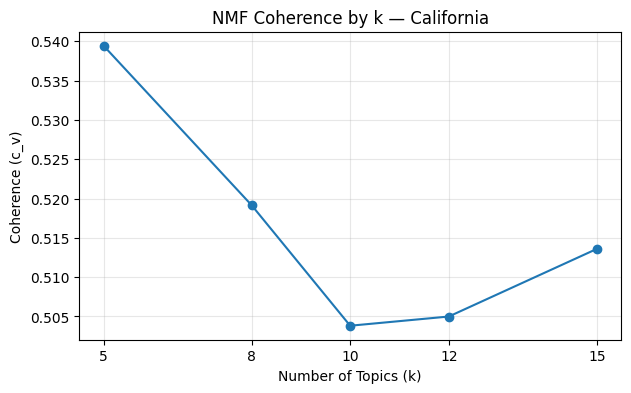

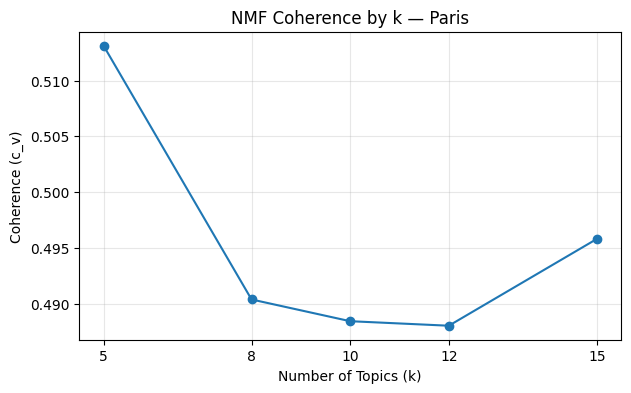

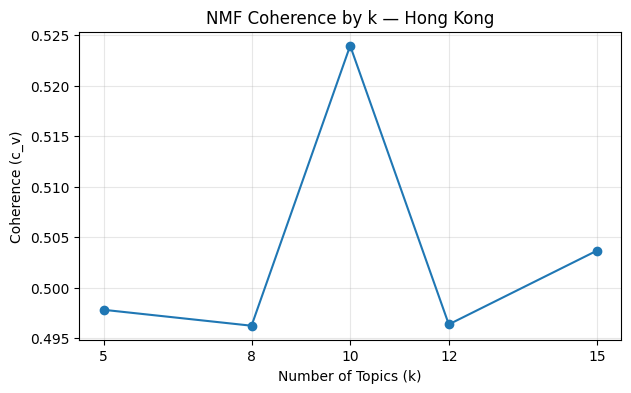

In [12]:
for group in target_groups:
    temp = nmf_artifacts[group]["results_df"].sort_values("k")

    plt.figure(figsize=(7,4))
    plt.plot(temp["k"], temp["coherence_c_v"], marker="o")
    plt.title(f"NMF Coherence by k — {group}")
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Coherence (c_v)")
    plt.xticks(temp["k"])
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Topic prevalence tables

In [13]:
nmf_prevalence_tables = {}

for group in target_groups:
    k = selected_k[group]
    doc_topic = nmf_artifacts[group]["fitted_models"][k]["doc_topic"]

    normalized = doc_topic / doc_topic.sum(axis=1, keepdims=True)
    prevalence = normalized.mean(axis=0)

    prevalence_df = pd.DataFrame({
        "topic_id": np.arange(1, len(prevalence) + 1),
        "avg_topic_probability": prevalence
    })

    nmf_prevalence_tables[group] = prevalence_df

    print(f"\nTopic prevalence for {group}")
    display(prevalence_df)


Topic prevalence for California


,topic_id,avg_topic_probability
0,1,0.162562
1,2,0.085998
2,3,0.069937
3,4,0.038338
4,5,0.115497
5,6,0.140324
6,7,0.101749
7,8,0.069744
8,9,0.124306
9,10,0.091546



Topic prevalence for Paris


,topic_id,avg_topic_probability
0,1,0.108259
1,2,0.145878
2,3,0.077474
3,4,0.057976
4,5,0.079708
5,6,0.115407
6,7,0.075558
7,8,0.137746
8,9,0.108883
9,10,0.093113



Topic prevalence for Hong Kong


,topic_id,avg_topic_probability
0,1,0.089397
1,2,0.084088
2,3,0.134837
3,4,0.111057
4,5,0.075172
5,6,0.061597
6,7,0.057050
7,8,0.171730
8,9,0.121277
9,10,0.093795


## 12. Visualize prevalence for each park

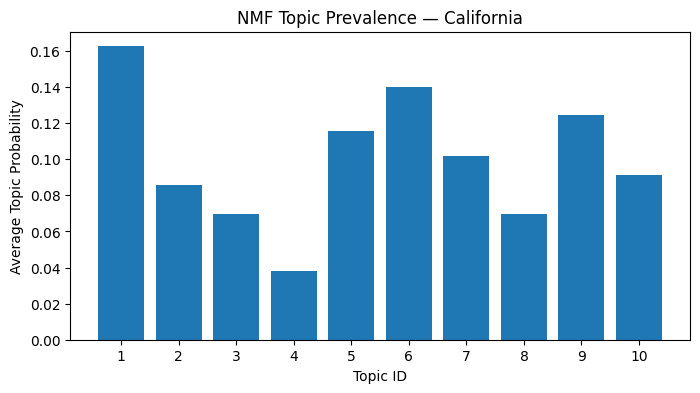

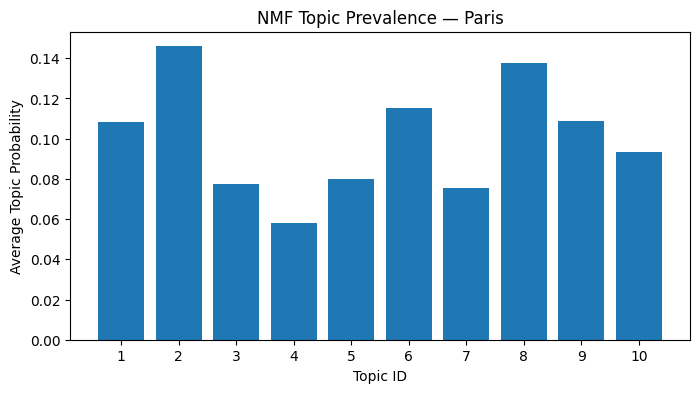

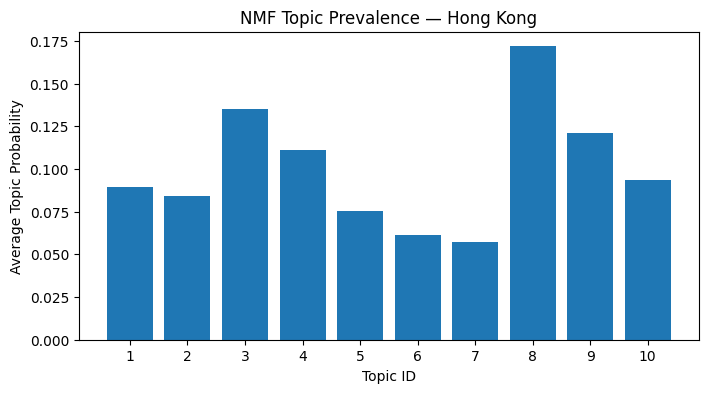

In [14]:
for group in target_groups:
    prev = nmf_prevalence_tables[group]

    plt.figure(figsize=(8,4))
    plt.bar(prev["topic_id"].astype(str), prev["avg_topic_probability"])
    plt.title(f"NMF Topic Prevalence — {group}")
    plt.xlabel("Topic ID")
    plt.ylabel("Average Topic Probability")
    plt.show()

## 13. Cross-group comparison chart

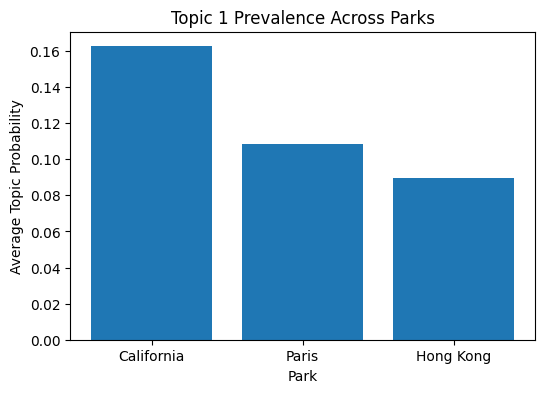

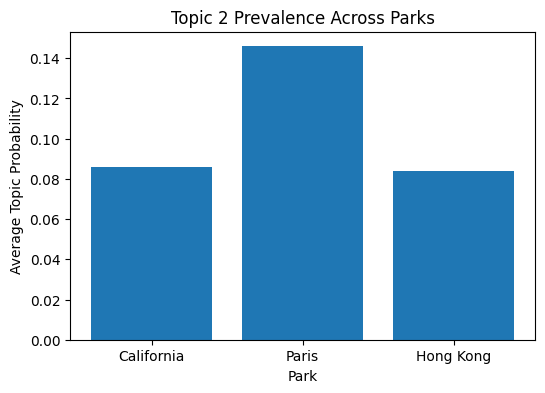

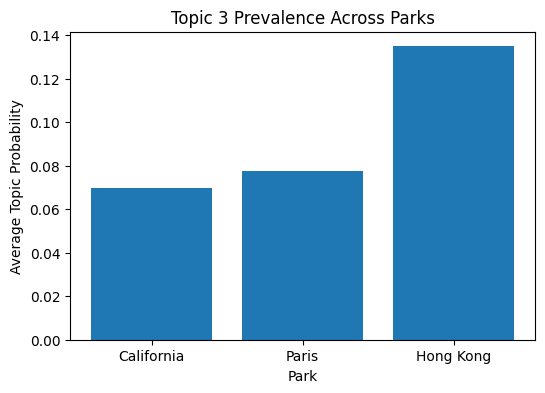

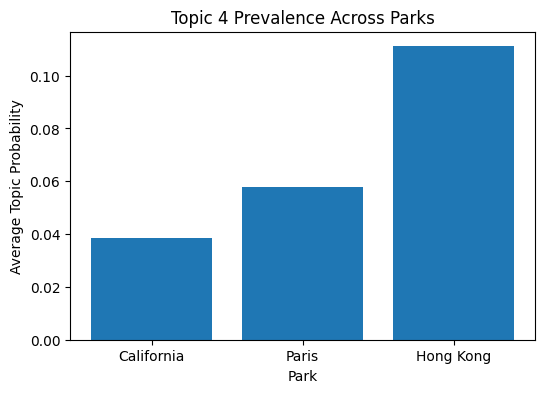

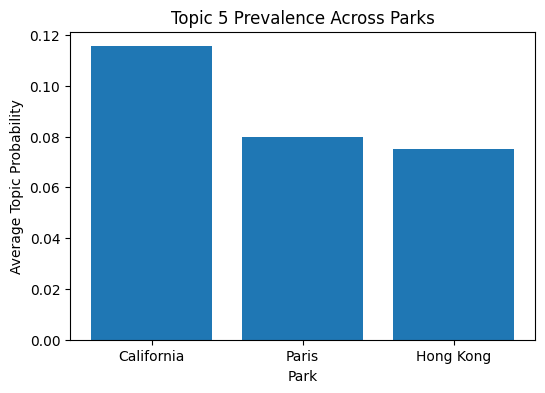

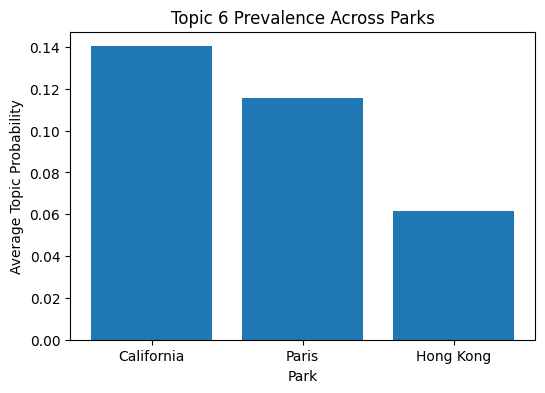

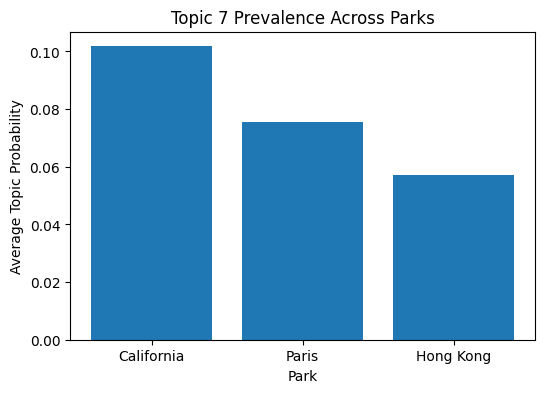

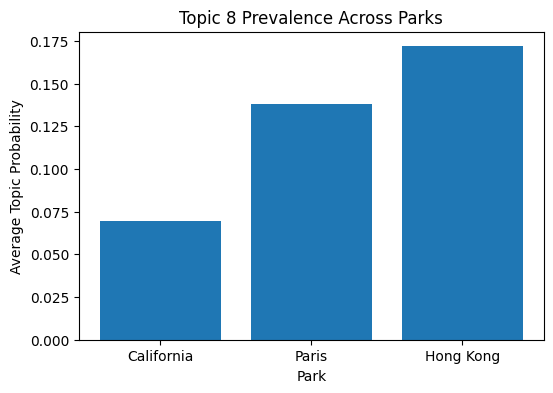

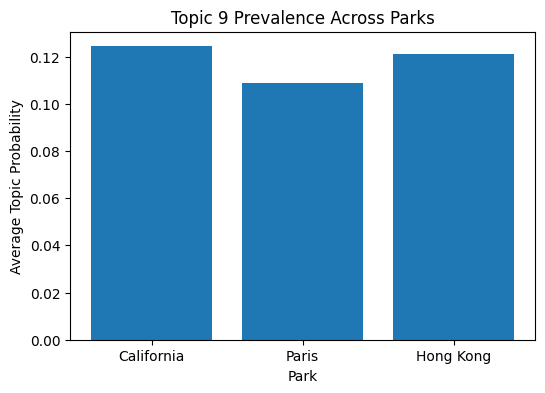

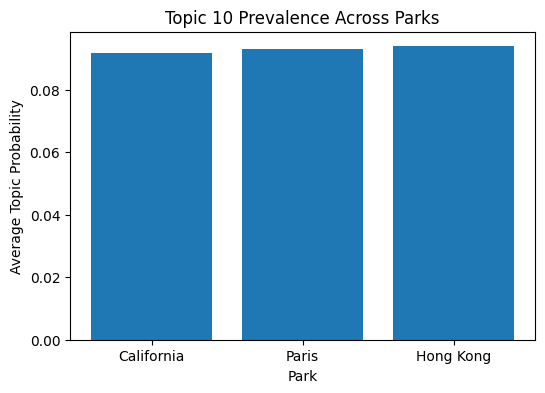

In [15]:
combined = []

for group in target_groups:
    temp = nmf_prevalence_tables[group].copy()
    temp["group"] = group
    combined.append(temp)

combined_df = pd.concat(combined, ignore_index=True)

for topic in combined_df["topic_id"].unique():
    subset = combined_df[combined_df["topic_id"] == topic]

    plt.figure(figsize=(6,4))
    plt.bar(subset["group"], subset["avg_topic_probability"])
    plt.title(f"Topic {topic} Prevalence Across Parks")
    plt.xlabel("Park")
    plt.ylabel("Average Topic Probability")
    plt.show()

## 14. Representative documents

In [16]:
def get_top_docs(subset_df, doc_topic_matrix, top_n_docs=8):
    normalized = doc_topic_matrix / doc_topic_matrix.sum(axis=1, keepdims=True)
    rows = []

    for topic_idx in range(normalized.shape[1]):
        topic_scores = normalized[:, topic_idx]
        top_doc_ids = np.argsort(topic_scores)[::-1][:top_n_docs]

        for rank, doc_id in enumerate(top_doc_ids, start=1):
            rows.append({
                "topic_id": topic_idx + 1,
                "rank_within_topic": rank,
                "topic_probability": round(float(topic_scores[doc_id]), 4),
                "review_text": subset_df.iloc[doc_id]["review_text"]
            })

    return pd.DataFrame(rows)

In [17]:
nmf_top_docs = {}

for group in target_groups:
    k = selected_k[group]
    fitted = nmf_artifacts[group]["fitted_models"][k]
    subset = nmf_artifacts[group]["subset"]

    top_docs_df = get_top_docs(subset, fitted["doc_topic"], top_n_docs=8)
    nmf_top_docs[group] = top_docs_df

    print(f"\nRepresentative docs for {group}")
    display(top_docs_df.head(20))


Representative docs for California


,topic_id,rank_within_topic,topic_probability,review_text
0,1,1,1.0000,We had a great time at the park but it was a l...
1,1,2,1.0000,It's ok. It's really expensive for not that mu...
2,1,3,1.0000,We went on a Tuesday. It was perfect! No long ...
3,1,4,1.0000,If you enjoy spending $92.00 a day to wait in ...
4,1,5,1.0000,Went in January of MLK weekend. Very few long...
5,1,6,1.0000,Too many people; too many long lines; too expe...
6,1,7,1.0000,we went during Spring Break.....wait times wer...
7,1,8,1.0000,People in wheelchairs and people using canes h...
8,2,1,1.0000,It's hard not to have a good time a Disneyland...
9,2,2,1.0000,Check out the Fast Pass at the entrance to the...



Representative docs for Paris


,topic_id,rank_within_topic,topic_probability,review_text
0,1,1,0.9862,We had a good time we stayed in the Cheyenne h...
1,1,2,0.9778,We stayed at the Sequoia Lodge hotel on site a...
2,1,3,0.9573,very good trip. Did Eurostar then stayed at th...
3,1,4,0.9417,Enjoyed the two days in the park. Very busy bu...
4,1,5,0.9223,Everything you expect from Disneyland. We stay...
5,1,6,0.8856,"great hotel, good food, clean .... good parks...."
6,1,7,0.8846,Have been here twice and loved both timesOnly ...
7,1,8,0.8823,Stayed at Newport Bay Hotel having travelled E...
8,2,1,1.0000,WOW the show at 11pm is amazing if you going d...
9,2,2,1.0000,Just outstanding on the Christmas day. Absolut...



Representative docs for Hong Kong


,topic_id,rank_within_topic,topic_probability,review_text
0,1,1,1.0000,Very expensive .. Food tasteless Burger wa...
1,1,2,0.9969,Although name is big but could not find anythi...
2,1,3,0.9944,I like all its places just the food options ar...
3,1,4,0.9783,The park is great but if you are going to char...
4,1,5,0.9573,The rides are good but the food choices are di...
5,1,6,0.9405,I had fun there and the problems is for travel...
6,1,7,0.9347,We can take the food pack the food properly an...
7,1,8,0.9270,Great place to spend at. our issue is for hala...
8,2,1,0.9615,a place you need to visit when you go to Hong ...
9,2,2,0.9411,I wasn't sure whether I was in Paris or in Hon...


## 15. Save outputs

In [18]:
import os
import pickle

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

for group in target_groups:
    k = selected_k[group]
    fitted = nmf_artifacts[group]["fitted_models"][k]
    safe_group = group.lower().replace(" ", "_")

    with open(f"models/nmf_{safe_group}_k{k}.pkl", "wb") as f:
        pickle.dump(fitted, f)

    nmf_topic_tables[group].to_csv(f"results/nmf_topics_{safe_group}.csv", index=False)
    nmf_prevalence_tables[group].to_csv(f"results/nmf_prevalence_{safe_group}.csv", index=False)
    nmf_top_docs[group].to_csv(f"results/nmf_top_docs_{safe_group}.csv", index=False)

print("Saved all NMF outputs.")

Saved all NMF outputs.


## 16. Save model

In [19]:
import os
import pickle

os.makedirs("models", exist_ok=True)

for group in target_groups:
    k = selected_k[group]
    fitted = nmf_artifacts[group]["fitted_models"][k]
    safe = group.lower().replace(" ", "_")

    path = f"models/nmf_{safe}_k{k}.pkl"

    with open(path, "wb") as f:
        pickle.dump(fitted, f)

    print(f"Saved: {path}")

Saved: models/nmf_california_k10.pkl
Saved: models/nmf_paris_k10.pkl
Saved: models/nmf_hong_kong_k10.pkl
